# Stroke Prediction — Machine Learning Assignment
**Course:** Fundamentals of Machine Learning  
**Group Members:**
- Member 1: Karunarathna P.K.A.L. | [ms26901626@my.sliit.lk]
- Member 2: Pandipperuma R.T. | [ms26901008@my.sliit.lk]

**Dataset:** Stroke Prediction Dataset  
**Source:** https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset  
**Algorithms:** Logistic Regression (Member 1) | Random Forest (Member 2)  



## SECTION 1: Import Libraries


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Class imbalance handling
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully.')

All libraries imported successfully.


## SECTION 2: Load Dataset

In [58]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:', list(df.columns))
df.head(10)

Dataset Shape: (5110, 12)

Column Names: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


## SECTION 3: Exploratory Data Analysis (EDA)

In [59]:
# Dataset overview
print('Basic Info')
df.info()
print('\nStatistical Summary')
print(df.describe())

Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Statistical Summary
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.00000

In [60]:
# Missing values and class distribution
print('Missing Values')
print(df.isnull().sum())
print('\nTarget Class Distribution')
print(df['stroke'].value_counts())
print(f'\nStroke rate: {df["stroke"].mean()*100:.2f}%')
print('Note: Severe class imbalance — only ~5% are positive stroke cases.')

Missing Values
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Target Class Distribution
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke rate: 4.87%
Note: Severe class imbalance — only ~5% are positive stroke cases.


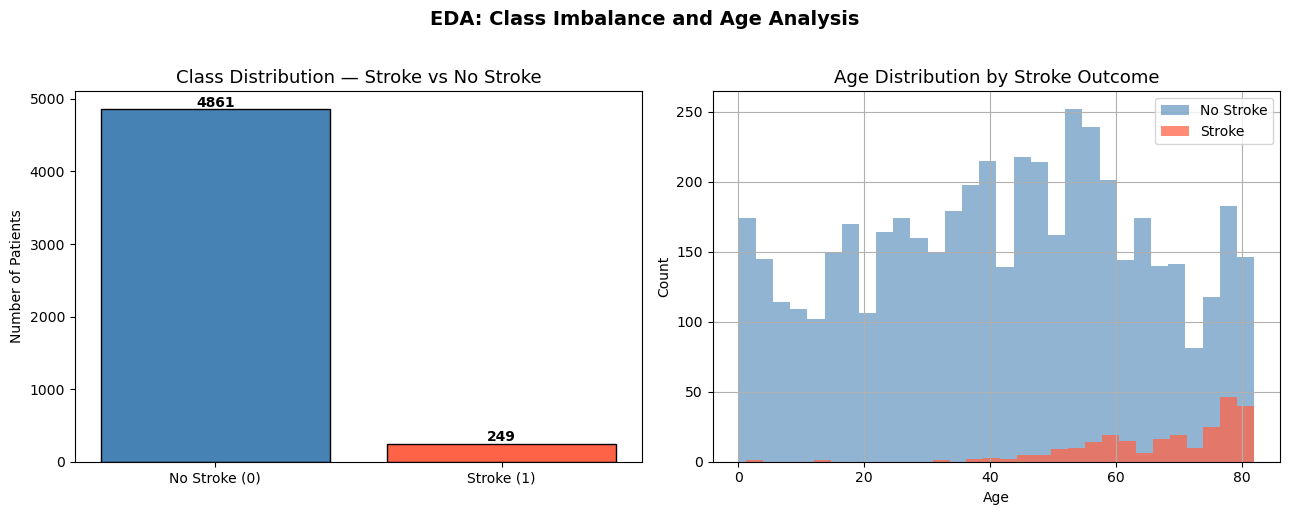

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Class imbalance
counts = df['stroke'].value_counts()
axes[0].bar(['No Stroke (0)', 'Stroke (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution — Stroke vs No Stroke', fontsize=13)
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Plot 2: Age distribution by stroke outcome
df[df['stroke'] == 0]['age'].hist(bins=30, ax=axes[1], alpha=0.6, color='steelblue', label='No Stroke')
df[df['stroke'] == 1]['age'].hist(bins=30, ax=axes[1], alpha=0.75, color='tomato', label='Stroke')
axes[1].set_title('Age Distribution by Stroke Outcome', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('EDA: Class Imbalance and Age Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_age.png', dpi=150, bbox_inches='tight')
plt.show()

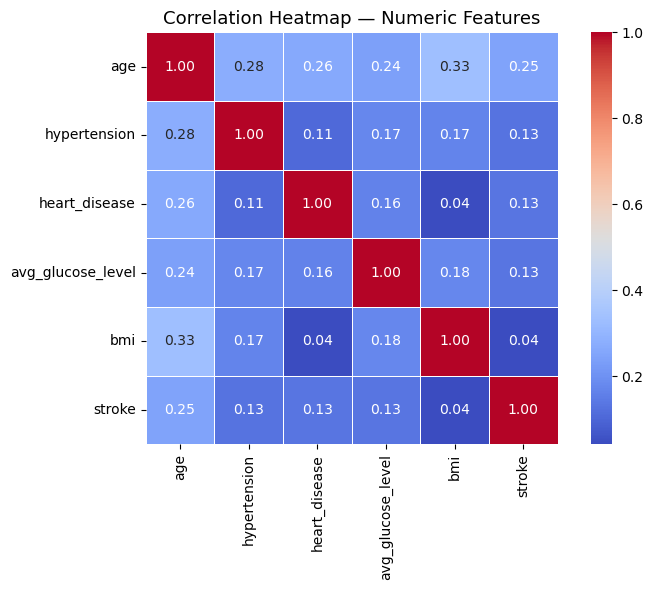

In [62]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['id'])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 4: Data Preprocessing

In [63]:
# Step 1: Drop 'id' — not a predictive feature
df = df.drop(columns=['id'])

# Step 2: Remove the single 'Other' gender row (too rare, causes encoding issues)
df = df[df['gender'] != 'Other']
print(f'Shape after removing "Other" gender: {df.shape}')

# Step 3: Impute missing 'bmi' values with the median (robust to outliers)
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f'Missing BMI values filled with median: {bmi_median:.2f}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Shape after removing "Other" gender: (5109, 11)
Missing BMI values filled with median: 28.10
Remaining missing values: 0


In [64]:
# Step 4: Label encode binary categorical columns
le = LabelEncoder()
df['gender']         = le.fit_transform(df['gender'])          # Female=0, Male=1
df['ever_married']   = le.fit_transform(df['ever_married'])    # No=0, Yes=1
df['Residence_type'] = le.fit_transform(df['Residence_type'])  # Rural=0, Urban=1

# Step 5: One-hot encode multi-class categorical columns
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True)

print(f'Shape after encoding: {df.shape}')
print('Final columns:', list(df.columns))

Shape after encoding: (5109, 16)
Final columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [65]:
# Step 6: Separate features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Step 7: Stratified 80/20 train-test split (preserves class ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train set: {X_train.shape} | Test set: {X_test.shape}')
print(f'Train class dist: {y_train.value_counts().to_dict()}')
print(f'Test  class dist: {y_test.value_counts().to_dict()}')

Train set: (4087, 15) | Test set: (1022, 15)
Train class dist: {0: 3888, 1: 199}
Test  class dist: {0: 972, 1: 50}


In [66]:
# Step 8: Apply SMOTE ONLY on training data to fix class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After SMOTE — Train shape: {X_train_sm.shape}')
print(f'After SMOTE — Class dist: {pd.Series(y_train_sm).value_counts().to_dict()}')
print('Class imbalance resolved: both classes now have equal representation.')

After SMOTE — Train shape: (7776, 15)
After SMOTE — Class dist: {0: 3888, 1: 3888}
Class imbalance resolved: both classes now have equal representation.


## SECTION 5: Logistic Regression - Member 1 (Karunarathna P.K.A.L.)

In [67]:
# Feature scaling
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_sm) 
X_test_lr  = scaler.transform(X_test)         

# Train logistic regression
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_lr, y_train_sm)

print('Logistic Regression model trained.')

Logistic Regression model trained.


In [68]:
# 5-Fold cross validation on training data
lr_cv = cross_val_score(lr_model, X_train_lr, y_train_sm, cv=5, scoring='roc_auc')
print(f'LR Cross-Validation ROC-AUC (5-fold): {lr_cv.round(4)}')
print(f'Mean: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')

LR Cross-Validation ROC-AUC (5-fold): [0.8842 0.9509 0.9481 0.9607 0.9548]
Mean: 0.9397 ± 0.0281


In [69]:
# Predictions on test set
lr_pred       = lr_model.predict(X_test_lr)
lr_pred_proba = lr_model.predict_proba(X_test_lr)[:, 1]

# Compute all evaluation metrics
lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr_pred_proba)

print('Logistic Regression — Evaluation Results')
print(f'  Accuracy  : {lr_acc:.4f}')
print(f'  Precision : {lr_prec:.4f}')
print(f'  Recall    : {lr_rec:.4f}')
print(f'  F1-Score  : {lr_f1:.4f}')
print(f'  ROC-AUC   : {lr_auc:.4f}')
print('\n' + classification_report(y_test, lr_pred, target_names=['No Stroke', 'Stroke']))

Logistic Regression — Evaluation Results
  Accuracy  : 0.8434
  Precision : 0.1687
  Recall    : 0.5600
  F1-Score  : 0.2593
  ROC-AUC   : 0.7784

              precision    recall  f1-score   support

   No Stroke       0.97      0.86      0.91       972
      Stroke       0.17      0.56      0.26        50

    accuracy                           0.84      1022
   macro avg       0.57      0.71      0.59      1022
weighted avg       0.93      0.84      0.88      1022



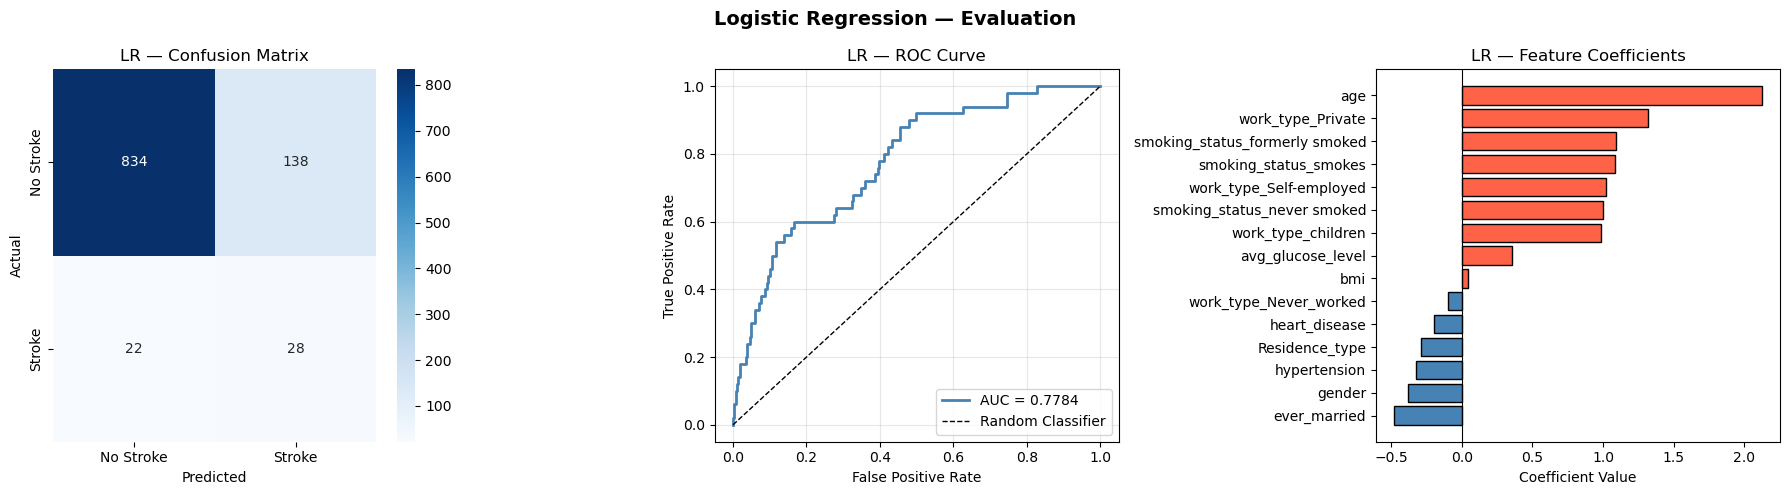

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
axes[0].set_title('LR — Confusion Matrix', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
axes[1].plot(fpr_lr, tpr_lr, color='steelblue', lw=2, label=f'AUC = {lr_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('LR — ROC Curve', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# Plot 3: Feature Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=True)
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('LR — Feature Coefficients', fontsize=12)
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_results.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 6: Random Forest - Member 2 (Pandipperuma R.T.)

In [71]:
# Train Random Forest (uses un-scaled data — tree-based models are scale-invariant)
rf_model = RandomForestClassifier(
    n_estimators=100,   # Number of trees
    max_depth=10,       # Limit tree depth to prevent overfitting
    random_state=42,
    n_jobs=-1           # Use all CPU cores
)
rf_model.fit(X_train_sm, y_train_sm)

print('Random Forest model trained.')

Random Forest model trained.


In [72]:
# 5-Fold Cross-Validation on training data
rf_cv = cross_val_score(rf_model, X_train_sm, y_train_sm, cv=5, scoring='roc_auc')
print(f'RF Cross-Validation ROC-AUC (5-fold): {rf_cv.round(4)}')
print(f'Mean: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

RF Cross-Validation ROC-AUC (5-fold): [0.9581 0.9926 0.9907 0.9937 0.9909]
Mean: 0.9852 ± 0.0136


In [73]:
# Predictions on test set
rf_pred       = rf_model.predict(X_test)           # No scaling needed
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Compute all evaluation metrics
rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf_pred_proba)

print('Random Forest Evaluation Results')
print(f'  Accuracy  : {rf_acc:.4f}')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_rec:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}')
print(f'  ROC-AUC   : {rf_auc:.4f}')
print('\n' + classification_report(y_test, rf_pred, target_names=['No Stroke', 'Stroke']))

Random Forest Evaluation Results
  Accuracy  : 0.8787
  Precision : 0.1636
  Recall    : 0.3600
  F1-Score  : 0.2250
  ROC-AUC   : 0.7726

              precision    recall  f1-score   support

   No Stroke       0.96      0.91      0.93       972
      Stroke       0.16      0.36      0.23        50

    accuracy                           0.88      1022
   macro avg       0.56      0.63      0.58      1022
weighted avg       0.93      0.88      0.90      1022



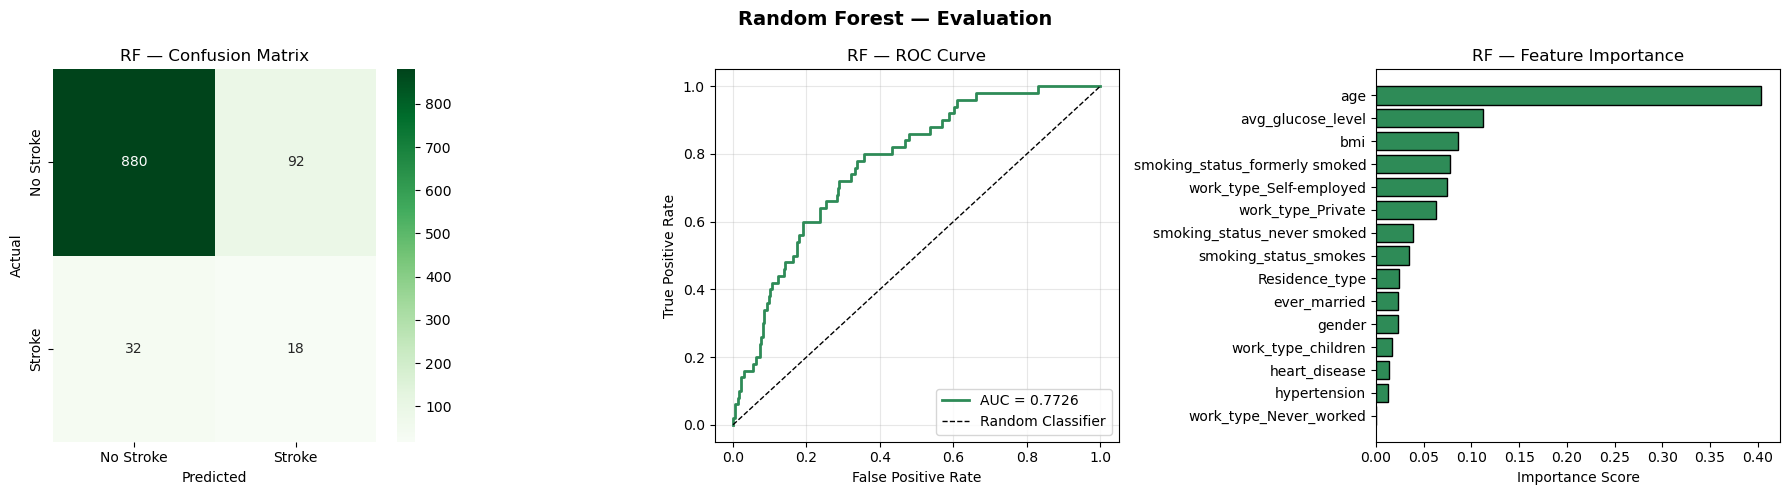

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
axes[0].set_title('RF — Confusion Matrix', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
axes[1].plot(fpr_rf, tpr_rf, color='seagreen', lw=2, label=f'AUC = {rf_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('RF — ROC Curve', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# Plot 3: Feature Importance
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)
axes[2].barh(feat_imp['Feature'], feat_imp['Importance'], color='seagreen', edgecolor='black')
axes[2].set_title('RF — Feature Importance', fontsize=12)
axes[2].set_xlabel('Importance Score')

plt.suptitle('Random Forest — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_results.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 7: Algorithm Comparison

In [75]:
# Side-by-side metrics table
comparison_df = pd.DataFrame({
    'Metric':              ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [lr_acc, lr_prec, lr_rec, lr_f1, lr_auc],
    'Random Forest':       [rf_acc, rf_prec, rf_rec, rf_f1, rf_auc],
})
comparison_df = comparison_df.set_index('Metric').round(4)

print('Algorithm Comparison Table')
print(comparison_df.to_string())

Algorithm Comparison Table
           Logistic Regression  Random Forest
Metric                                       
Accuracy                0.8434         0.8787
Precision               0.1687         0.1636
Recall                  0.5600         0.3600
F1-Score                0.2593         0.2250
ROC-AUC                 0.7784         0.7726


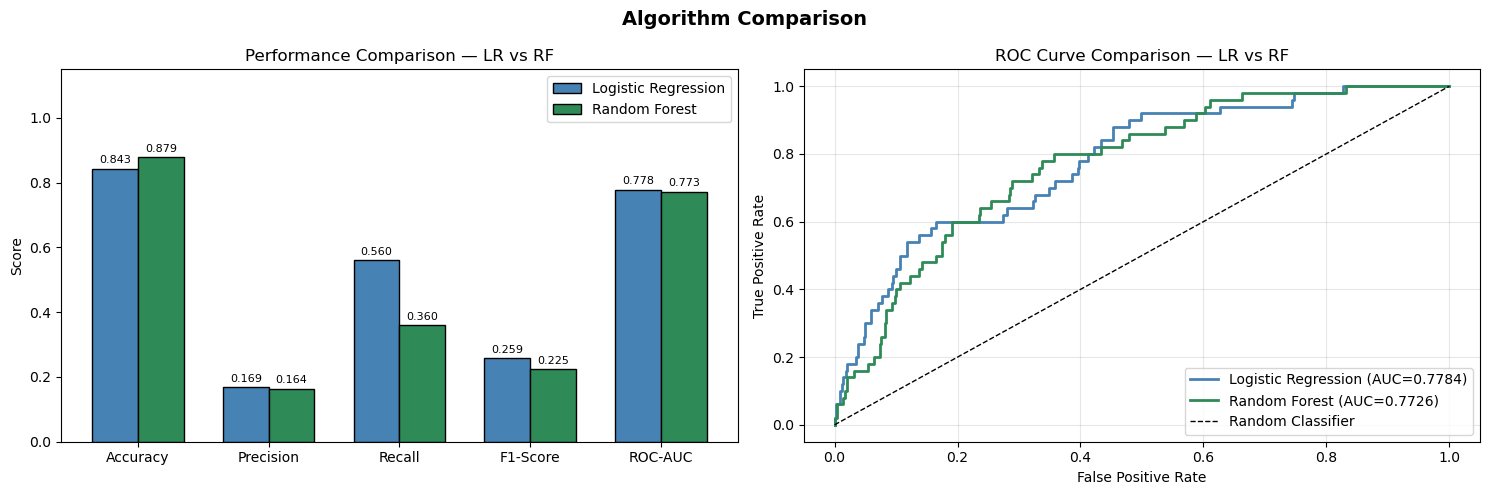

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Grouped bar chart of all metrics
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_vals = [lr_acc, lr_prec, lr_rec, lr_f1, lr_auc]
rf_vals = [rf_acc, rf_prec, rf_rec, rf_f1, rf_auc]
x = np.arange(len(metrics_list))
w = 0.35

bars1 = axes[0].bar(x - w/2, lr_vals, w, label='Logistic Regression', color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x + w/2, rf_vals, w, label='Random Forest',       color='seagreen',  edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_list)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Comparison — LR vs RF', fontsize=12)
axes[0].legend()
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Combined ROC Curves
axes[1].plot(fpr_lr, tpr_lr, color='steelblue', lw=2, label=f'Logistic Regression (AUC={lr_auc:.4f})')
axes[1].plot(fpr_rf, tpr_rf, color='seagreen',  lw=2, label=f'Random Forest (AUC={rf_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison — LR vs RF', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Algorithm Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [77]:
# Final summary printout
print('           FINAL RESULTS SUMMARY')
print(comparison_df.to_string())
winner = 'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'
print(f'Best performing model by ROC-AUC: {winner}')

           FINAL RESULTS SUMMARY
           Logistic Regression  Random Forest
Metric                                       
Accuracy                0.8434         0.8787
Precision               0.1687         0.1636
Recall                  0.5600         0.3600
F1-Score                0.2593         0.2250
ROC-AUC                 0.7784         0.7726
Best performing model by ROC-AUC: Logistic Regression
